# RoBERTa Multi-Class Diagnosis Models

Trains **two** RoBERTa classifiers on `generated_augmented_suicidewatch_filtered_optimisticadded_data`:

1. **3-class severity model** — predicts `threeclass_label`.
2. **Subreddit model** — predicts `multiclass_label` (after dropping ultra-rare classes).

Each model gets its own 80/10/10 stratified split, class-weighted loss, and checkpoint.


**Data Version:** v7 same as the v6 dataset but filtered suicide watch again


## Section 1: Imports

In [1]:
import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
)
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')


## Section 2: Load `generated_augmented_suicidewatch_filtered_optimisticadded_data` and minimal preprocessing

In [2]:
generated_augmented_suicidewatch_filtered_optimisticadded_data=pd.read_csv("generated_augmented_suicidewatch_filtered_optimisticadded_data.csv")

In [3]:
# generated_augmented_suicidewatch_filtered_optimisticadded_data is expected to already exist in the kernel with columns:
#   other_posts, multiclass_label, threeclass_label
# If you need to load it from disk, uncomment the line below:
# generated_augmented_suicidewatch_filtered_optimisticadded_data = pd.read_csv('generated_augmented_suicidewatch_filtered_optimisticadded_data.csv')

data = generated_augmented_suicidewatch_filtered_optimisticadded_data.sample(frac=1, random_state=42).reset_index(drop=True)

print('Dataset shape:', data.shape)
print('\nColumns:', data.columns.tolist())
print('\nthreeclass_label distribution:')
print(data['threeclass_label'].value_counts(dropna=False))
print('\nmulticlass_label distribution:')
print(data['multiclass_label'].value_counts(dropna=False))

Dataset shape: (68769, 33)

Columns: ['author', 'subreddit', 'report_post', 'other_posts', 'is_self_report', 'is_control', 'self_report_sentence', 'selfdiag_score', 'selfdiag_matches', 'severe_flag', 'label', 'multiclass_label', 'threeclass_label', 'clean_text', 'emotion_matches', 'emotion_score', 'emotion_hits', 'emotion_triggered_patterns', 'has_risk_leakage', 'risk_hits', 'word_count', 'control_emotion_decision', 'source', 'matches', 'score', 'decision', 'text', 'fiveclass_label', 'risk', 'is_emotional_control', 'emotion_type', 'sentiment', 'length_bucket']

threeclass_label distribution:
threeclass_label
at_risk     58015
normal       7846
suicidal     2403
control       505
Name: count, dtype: int64

multiclass_label distribution:
multiclass_label
adhd             12592
control          10192
anxiety          10107
depression        9157
mentalhealth      8112
socialanxiety     2989
bpd               2926
ptsd              2637
suicidewatch      2403
autism            1661
schizop

In [ ]:
def minimal_preprocess(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data['other_posts'] = data['other_posts'].apply(minimal_preprocess)
data = data[data['other_posts'].str.len() > 0].reset_index(drop=True)
print(f'After cleaning empty text: {len(data)} rows')

After cleaning empty text: 67987 rows


## Section 3: Shared building blocks (Dataset, train, eval)

In [ ]:
class TextClassificationDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(np.asarray(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item


def train_epoch(model, train_loader, optimizer, scheduler, device, loss_fn):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc='Training'):
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch.pop('labels')
        outputs = model(**batch)
        loss = loss_fn(outputs.logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)


def evaluate(model, eval_loader, device, loss_fn):
    model.eval()
    total_loss = 0
    predictions, true_labels = [], []
    with torch.no_grad():
        for batch in tqdm(eval_loader, desc='Evaluating'):
            batch = {k: v.to(device) for k, v in batch.items()}
            labels = batch.pop('labels')
            outputs = model(**batch)
            loss = loss_fn(outputs.logits, labels)
            total_loss += loss.item()
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            predictions.extend(preds)
            true_labels.extend(labels.cpu().numpy())
    return total_loss / len(eval_loader), accuracy_score(true_labels, predictions), predictions, true_labels


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

MODEL_NAME = 'roberta-base'
tokenizer = RobertaTokenizerFast.from_pretrained(MODEL_NAME)
MAX_LENGTH = 256
BATCH_SIZE = 16
NUM_EPOCHS = 5
LEARNING_RATE = 2e-5

Using device: cuda


## Section 4: End-to-end training function

Given a dataframe + label column, this prepares splits, encodes labels, computes class weights, trains a RoBERTa model, and reports macro / weighted P/R/F1 plus a confusion matrix. We call it twice — once per label column.

In [ ]:
def run_experiment(df, label_col, model_save_path, min_samples_per_class=50):
    print('=' * 70)
    print(f'EXPERIMENT: {label_col}  ->  {model_save_path}')
    print('=' * 70)

    # 1. Drop NaN labels / empty text
    work = df.dropna(subset=[label_col, 'other_posts']).copy()

    # 2. Drop ultra-rare classes
    counts = work[label_col].value_counts()
    keep_classes = counts[counts >= min_samples_per_class].index.tolist()
    dropped = counts[counts < min_samples_per_class]
    if len(dropped) > 0:
        print(f'Dropping {len(dropped)} classes with < {min_samples_per_class} samples:')
        for cls, n in dropped.items():
            print(f'  - {cls}: {n}')
    work = work[work[label_col].isin(keep_classes)].reset_index(drop=True)

    # 3. Encode string labels -> integers
    le = LabelEncoder()
    work['_y'] = le.fit_transform(work[label_col].astype(str))
    class_names = list(le.classes_)
    num_labels = len(class_names)
    print(f'\nFinal: {len(work)} rows, {num_labels} classes')
    print('Class distribution:')
    for i, name in enumerate(class_names):
        print(f'  {i:2d} {name:<25} {(work["_y"] == i).sum()}')

    # 4. 80/10/10 stratified split
    train_df, temp_df = train_test_split(work, test_size=0.2, random_state=42, stratify=work['_y'])
    val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['_y'])
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)
    print(f'\nSplit sizes: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}')

    # 5. Tokenize
    def tok(texts):
        return tokenizer(texts.tolist(), max_length=MAX_LENGTH, padding='max_length',
                         truncation=True, return_tensors='pt')

    print('\nTokenizing...')
    train_enc = tok(train_df['other_posts'])
    val_enc = tok(val_df['other_posts'])
    test_enc = tok(test_df['other_posts'])

    train_ds = TextClassificationDataset(train_enc, train_df['_y'].values)
    val_ds = TextClassificationDataset(val_enc, val_df['_y'].values)
    test_ds = TextClassificationDataset(test_enc, test_df['_y'].values)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    # 6. Model + class-weighted loss
    id2label = {i: n for i, n in enumerate(class_names)}
    label2id = {n: i for i, n in enumerate(class_names)}
    model = RobertaForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
    ).to(device)

    cw = compute_class_weight('balanced', classes=np.arange(num_labels), y=train_df['_y'].values)
    class_weights = torch.tensor(cw, dtype=torch.float).to(device)
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)
    print(f'\nClass weights computed (min={cw.min():.3f}, max={cw.max():.3f})')

    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
    total_steps = len(train_loader) * NUM_EPOCHS
    scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, total_iters=total_steps)

    # 7. Training loop — select on macro-F1
    best_val_f1 = 0.0
    for epoch in range(NUM_EPOCHS):
        print(f'\n--- Epoch {epoch + 1}/{NUM_EPOCHS} ---')
        train_loss = train_epoch(model, train_loader, optimizer, scheduler, device, loss_fn)
        print(f'Train loss: {train_loss:.4f}')
        val_loss, val_acc, val_preds, val_true = evaluate(model, val_loader, device, loss_fn)
        val_macro_f1 = f1_score(val_true, val_preds, average='macro', zero_division=0)
        print(f'Val loss: {val_loss:.4f}  acc: {val_acc:.4f}  macro-F1: {val_macro_f1:.4f}')
        if val_macro_f1 > best_val_f1:
            best_val_f1 = val_macro_f1
            torch.save(model.state_dict(), model_save_path)
            print(f'  -> saved best model to {model_save_path}')

    # 8. Final test eval with best checkpoint
    model.load_state_dict(torch.load(model_save_path))
    test_loss, test_acc, test_preds, test_true = evaluate(model, test_loader, device, loss_fn)
    print('\n' + '=' * 70)
    print(f'TEST RESULTS — {label_col}')
    print('=' * 70)
    print(f'Loss:        {test_loss:.4f}')
    print(f'Accuracy:    {test_acc:.4f}')
    print(f'Macro    P/R/F1: '
          f'{precision_score(test_true, test_preds, average="macro", zero_division=0):.4f} / '
          f'{recall_score(test_true, test_preds, average="macro", zero_division=0):.4f} / '
          f'{f1_score(test_true, test_preds, average="macro", zero_division=0):.4f}')
    print(f'Weighted P/R/F1: '
          f'{precision_score(test_true, test_preds, average="weighted", zero_division=0):.4f} / '
          f'{recall_score(test_true, test_preds, average="weighted", zero_division=0):.4f} / '
          f'{f1_score(test_true, test_preds, average="weighted", zero_division=0):.4f}')
    print('\nClassification report:')
    print(classification_report(test_true, test_preds, target_names=class_names, zero_division=0))
    print('Confusion matrix (rows=true, cols=pred):')
    cm = confusion_matrix(test_true, test_preds, labels=list(range(num_labels)))
    print(cm)

    return {
        'model': model,
        'label_encoder': le,
        'class_names': class_names,
        'test_acc': test_acc,
        'test_macro_f1': f1_score(test_true, test_preds, average='macro', zero_division=0),
    }


## Section 5: Train Model 1 — 3-class severity (`threeclass_label`)

In [ ]:
# result_3class = run_experiment(
#     df=data,
#     label_col='threeclass_label',
#     model_save_path='best_roberta_threeclass_v7.pt',
#     min_samples_per_class=50,
# )

## Section 6: Train Model 2 — Subreddit model (`multiclass_label`)

In [11]:
picked_classes=["adhd","anxiety","control" , "depression", "suicidewatch" ]
data = data[data['multiclass_label'].isin(picked_classes)].reset_index(drop=True)
result_multiclass = run_experiment(
    df=data,
    label_col='multiclass_label',
    model_save_path='best_roberta_multiclass_v7.pt',
    # min_samples_per_class=12000,  # drops jokes (6), covid19_support (37)
)

EXPERIMENT: multiclass_label  ->  best_roberta_multiclass_v7.pt

Final: 43801 rows, 5 classes
Class distribution:
   0 adhd                      12560
   1 anxiety                   10078
   2 control                   9687
   3 depression                9073
   4 suicidewatch              2403

Split sizes: train=35040, val=4380, test=4381

Tokenizing...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Class weights computed (min=0.697, max=3.646)

--- Epoch 1/5 ---


Training: 100%|██████████| 2190/2190 [16:13<00:00,  2.25it/s]


Train loss: 0.7200


...

Train loss: 0.1956


Evaluating: 100%|██████████| 274/274 [00:32<00:00,  8.41it/s]


Val loss: 0.3807  acc: 0.8970  macro-F1: 0.8979
  -> saved best model to best_roberta_multiclass_v7.pt


Evaluating: 100%|██████████| 274/274 [00:32<00:00,  8.40it/s]



TEST RESULTS — multiclass_label
Loss:        0.3790
Accuracy:    0.9012
Macro    P/R/F1: 0.9035 / 0.8963 / 0.8988
Weighted P/R/F1: 0.9016 / 0.9012 / 0.9002

Classification report:
              precision    recall  f1-score   support

        adhd       0.90      0.95      0.93      1256
     anxiety       0.86      0.90      0.88      1008
     control       0.96      0.95      0.95       969
  depression       0.89      0.78      0.83       908
suicidewatch       0.91      0.90      0.91       240

    accuracy                           0.90      4381
   macro avg       0.90      0.90      0.90      4381
weighted avg       0.90      0.90      0.90      4381

Confusion matrix (rows=true, cols=pred):
[[1199   33    3   21    0]
 [  60  908    8   29    3]
 [   6   22  918   18    5]
 [  68   94   26  707   13]
 [   1    2    5   16  216]]


## Section 7: Summary

In [12]:
print('=' * 60)
print('FINAL SUMMARY — RoBERTa')
print('=' * 60)
# print(f"3-class model    | classes={len(result_3class['class_names'])}    | "
#       f"test acc={result_3class['test_acc']:.4f} | macro-F1={result_3class['test_macro_f1']:.4f}")
print(f"Subreddit model  | classes={len(result_multiclass['class_names'])}   | "
      f"test acc={result_multiclass['test_acc']:.4f} | macro-F1={result_multiclass['test_macro_f1']:.4f}")

FINAL SUMMARY — RoBERTa
Subreddit model  | classes=5   | test acc=0.9012 | macro-F1=0.8988


In [13]:
# model = RobertaForSequenceClassification.from_pretrained(
#         MODEL_NAME,
#         num_labels=num_labels,
#         id2label=id2label,
#         label2id=label2id,
#     ).to(device)

# # Load best model for final evaluation
# model.load_state_dict(torch.load('best_roberta_threeclass.pt'))

# input_text= "I feel so empty inside. I don't know what to do anymore."
 
# input_text=minimal_preprocess(input_text)
# inputs = tokenizer(input_text, return_tensors="pt", truncation=True, padding=True, max_length=512)

# # Move inputs to the same device as the model
# inputs = {key: val.to(device) for key, val in inputs.items()}

# # Perform inference
# model.eval()
# with torch.no_grad():
# 	outputs = model(**inputs)
# 	logits = outputs.logits
# 	probs = torch.softmax(logits, dim=1)
# 	p1 = probs[:, 1]
# 	predicted_class = int(p1.item()>=0.1)
# print(logits)
# print(probs)
# print(f"Predicted class: {predicted_class}")


In [14]:
def predict_single(text, model_path, num_labels, class_names):
    """Predict the class of a single text input using a trained RoBERTa checkpoint."""
    # Rebuild model architecture and load weights
    id2label = {i: n for i, n in enumerate(class_names)}
    label2id = {n: i for i, n in enumerate(class_names)}
    model = RobertaForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
    ).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Preprocess + tokenize
    clean = minimal_preprocess(text)
    enc = tokenizer(
        clean,
        max_length=MAX_LENGTH,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
    ).to(device)

    # Forward pass
    with torch.no_grad():
        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    pred_idx = int(probs.argmax())
    pred_label = class_names[pred_idx]

    print(f'Input: {text[:120]}{"..." if len(text) > 120 else ""}')
    print(f'\nPredicted class: {pred_label}  (confidence: {probs[pred_idx]:.4f})')
    print('\nTop 5 probabilities:')
    top5 = np.argsort(probs)[::-1][:5]
    for i in top5:
        print(f'  {class_names[i]:<25} {probs[i]:.4f}')

    return pred_label, probs

In [15]:
# Example text
sample_text = "I've been feeling really overwhelmed lately, can't sleep, and everything feels pointless. I don't know what to do anymore."

# Predict with the 3-class severity model
# print('=== 3-class severity model ===')
# predict_single(
#     text=sample_text,
#     model_path='best_roberta_threeclass.pt',
#     num_labels=len(result_3class['class_names']),
#     class_names=result_3class['class_names'],
# )

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass_v7.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)


=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: I've been feeling really overwhelmed lately, can't sleep, and everything feels pointless. I don't know what to do anymor...

Predicted class: control  (confidence: 0.9748)

Top 5 probabilities:
  control                   0.9748
  adhd                      0.0199
  anxiety                   0.0041
  depression                0.0008
  suicidewatch              0.0004


('control',
 array([1.9949611e-02, 4.0762555e-03, 9.7481877e-01, 7.9077383e-04,
        3.6458165e-04], dtype=float32))

In [16]:
# Example text
sample_text = "I've been feeling really overwhelmed lately."

# Predict with the 3-class severity model
# print('=== 3-class severity model ===')
# predict_single(
#     text=sample_text,
#     model_path='best_roberta_threeclass.pt',
#     num_labels=len(result_3class['class_names']),
#     class_names=result_3class['class_names'],
# )

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass_v7.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)


=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: I've been feeling really overwhelmed lately.

Predicted class: adhd  (confidence: 0.5785)

Top 5 probabilities:
  adhd                      0.5785
  control                   0.4104
  anxiety                   0.0067
  suicidewatch              0.0029
  depression                0.0014


('adhd',
 array([0.578541  , 0.00670762, 0.41044495, 0.0014182 , 0.00288819],
       dtype=float32))

In [17]:
# Example text
sample_text = "I feel so empty inside. I don't know what to do anymore."

# Predict with the 3-class severity model
# print('=== 3-class severity model ===')
# predict_single(
#     text=sample_text,
#     model_path='best_roberta_threeclass.pt',
#     num_labels=len(result_3class['class_names']),
#     class_names=result_3class['class_names'],
# )

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass_v7.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)


=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: I feel so empty inside. I don't know what to do anymore.

Predicted class: depression  (confidence: 0.6089)

Top 5 probabilities:
  depression                0.6089
  control                   0.1896
  suicidewatch              0.1810
  anxiety                   0.0122
  adhd                      0.0082


('depression',
 array([0.00822936, 0.01222132, 0.18964891, 0.60885715, 0.18104321],
       dtype=float32))

In [18]:
# Example text
sample_text = "I don't know want to live anymore."

# Predict with the 3-class severity model
# print('=== 3-class severity model ===')
# predict_single(
#     text=sample_text,
#     model_path='best_roberta_threeclass.pt',
#     num_labels=len(result_3class['class_names']),
#     class_names=result_3class['class_names'],
# )

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass_v7.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)


=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: I don't know want to live anymore.

Predicted class: suicidewatch  (confidence: 0.9967)

Top 5 probabilities:
  suicidewatch              0.9967
  depression                0.0019
  anxiety                   0.0006
  adhd                      0.0005
  control                   0.0002


('suicidewatch',
 array([5.4459157e-04, 5.7570502e-04, 2.1942155e-04, 1.9479657e-03,
        9.9671233e-01], dtype=float32))

In [19]:
# Example text
sample_text = "I'm fine."

# Predict with the 3-class severity model
# print('=== 3-class severity model ===')
# predict_single(
#     text=sample_text,
#     model_path='best_roberta_threeclass.pt',
#     num_labels=len(result_3class['class_names']),
#     class_names=result_3class['class_names'],
# )

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass_v7.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)


=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: I'm fine.

Predicted class: anxiety  (confidence: 0.9517)

Top 5 probabilities:
  anxiety                   0.9517
  control                   0.0263
  depression                0.0159
  adhd                      0.0056
  suicidewatch              0.0005


('anxiety',
 array([5.6413133e-03, 9.5165592e-01, 2.6347188e-02, 1.5876830e-02,
        4.7874419e-04], dtype=float32))

In [20]:
# Example text
sample_text = "I'm fine.life seems okay.everything is good.just a bit stressed with work. so i'm a little worried about that."

# Predict with the 3-class severity model
# print('=== 3-class severity model ===')
# predict_single(
#     text=sample_text,
#     model_path='best_roberta_threeclass.pt',
#     num_labels=len(result_3class['class_names']),
#     class_names=result_3class['class_names'],
# )

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass_v7.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)


=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: I'm fine.life seems okay.everything is good.just a bit stressed with work. so i'm a little worried about that.

Predicted class: control  (confidence: 0.9812)

Top 5 probabilities:
  control                   0.9812
  anxiety                   0.0109
  adhd                      0.0048
  depression                0.0019
  suicidewatch              0.0011


('control',
 array([0.00483979, 0.01091383, 0.9812325 , 0.00192675, 0.0010871 ],
       dtype=float32))

In [21]:
# Example text
sample_text = "I'm fine.life seems okay.everything is good.just a bit stressed with work. so i'm a little worried about that."

# Predict with the 3-class severity model
# print('=== 3-class severity model ===')
# predict_single(
#     text=sample_text,
#     model_path='best_roberta_threeclass.pt',
#     num_labels=len(result_3class['class_names']),
#     class_names=result_3class['class_names'],
# )

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass_v7.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)


=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: I'm fine.life seems okay.everything is good.just a bit stressed with work. so i'm a little worried about that.

Predicted class: control  (confidence: 0.9812)

Top 5 probabilities:
  control                   0.9812
  anxiety                   0.0109
  adhd                      0.0048
  depression                0.0019
  suicidewatch              0.0011


('control',
 array([0.00483979, 0.01091383, 0.9812325 , 0.00192675, 0.0010871 ],
       dtype=float32))

In [22]:
# Example text
sample_text = "i can't foucs on anything latly , it's like my brain is just not working.\
i can't even read a book without losing focus after a few sentences."

# Predict with the 3-class severity model
# print('=== 3-class severity model ===')
# predict_single(
#     text=sample_text,
#     model_path='best_roberta_threeclass.pt',
#     num_labels=len(result_3class['class_names']),
#     class_names=result_3class['class_names'],
# )

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass_v7.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)


=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: i can't foucs on anything latly , it's like my brain is just not working.i can't even read a book without losing focus a...

Predicted class: adhd  (confidence: 0.9831)

Top 5 probabilities:
  adhd                      0.9831
  depression                0.0135
  anxiety                   0.0026
  control                   0.0006
  suicidewatch              0.0003


('adhd',
 array([9.8307377e-01, 2.5812807e-03, 5.7921832e-04, 1.3512714e-02,
        2.5297201e-04], dtype=float32))

In [23]:
# Example text
sample_text = "my brain is not letting me relax , i'm always worried about something\
    though i know can't fix everything but i can't stop overthinking" 


# Predict with the 3-class severity model
#  print('=== 3-class severity model ===')
# predict_single(
#     text=sample_text,
#     model_path='best_roberta_threeclass.pt',
#     num_labels=len(result_3class['class_names']),
#     class_names=result_3class['class_names'],
# )

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass_v7.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)


=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: my brain is not letting me relax , i'm always worried about something    though i know can't fix everything but i can't ...

Predicted class: anxiety  (confidence: 0.9584)

Top 5 probabilities:
  anxiety                   0.9584
  adhd                      0.0255
  depression                0.0142
  control                   0.0018
  suicidewatch              0.0001


('anxiety',
 array([2.5536362e-02, 9.5837921e-01, 1.8245480e-03, 1.4165912e-02,
        9.3993207e-05], dtype=float32))

In [24]:
# Example text
sample_text = "i'm feeling like i've lost passion on everything, i don't enjoy anything anymore \
                it does not make a difference for me if it is a small or big thing, i just don't care anymore." 


# Predict with the 3-class severity model
# print('=== 3-class severity model ===')
# predict_single(
#     text=sample_text,
#     model_path='best_roberta_threeclass.pt',
#     num_labels=len(result_3class['class_names']),
#     class_names=result_3class['class_names'],
# )

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass_v7.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)


=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: i'm feeling like i've lost passion on everything, i don't enjoy anything anymore                 it does not make a diff...

Predicted class: depression  (confidence: 0.9735)

Top 5 probabilities:
  depression                0.9735
  suicidewatch              0.0152
  adhd                      0.0060
  control                   0.0045
  anxiety                   0.0008


('depression',
 array([6.0228799e-03, 8.2273874e-04, 4.4777649e-03, 9.7351587e-01,
        1.5160822e-02], dtype=float32))

In [25]:
# Example text
sample_text = "i don't know how i feel, work is overloading me , and i feel prusure having to cop with everything , work, family and fun\
     but i can't denay that i'm greatful to the life i have  " 


# Predict with the 3-class severity model
# print('=== 3-class severity model ===')
# predict_single(
#     text=sample_text,
#     model_path='best_roberta_threeclass.pt',
#     num_labels=len(result_3class['class_names']),
#     class_names=result_3class['class_names'],
# )

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass_v7.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)


=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: i don't know how i feel, work is overloading me , and i feel prusure having to cop with everything , work, family and fu...

Predicted class: depression  (confidence: 0.6866)

Top 5 probabilities:
  depression                0.6866
  anxiety                   0.2509
  control                   0.0425
  adhd                      0.0193
  suicidewatch              0.0007


('depression',
 array([0.01930153, 0.25086758, 0.04252926, 0.68660134, 0.00070033],
       dtype=float32))

In [26]:
# Example text
sample_text = "the most annoying thing that i can't really take care of the people i love\
           i'm not taking enough care of my family and boyfrind  " 


# Predict with the 3-class severity model
# print('=== 3-class severity model ===')
# predict_single(
#     text=sample_text,
#     model_path='best_roberta_threeclass.pt',
#     num_labels=len(result_3class['class_names']),
#     class_names=result_3class['class_names'],
# )

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass_v7.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)


=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: the most annoying thing that i can't really take care of the people i love           i'm not taking enough care of my fa...

Predicted class: depression  (confidence: 0.7498)

Top 5 probabilities:
  depression                0.7498
  control                   0.1194
  adhd                      0.0780
  suicidewatch              0.0455
  anxiety                   0.0074


('depression',
 array([0.07797615, 0.0074129 , 0.11935776, 0.74975026, 0.04550289],
       dtype=float32))

In [27]:
# Example text
sample_text = "commiting suicide " 


# Predict with the 3-class severity model
# print('=== 3-class severity model ===')
# predict_single(
#     text=sample_text,
#     model_path='best_roberta_threeclass.pt',
#     num_labels=len(result_3class['class_names']),
#     class_names=result_3class['class_names'],
# )

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass_v7.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)


=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: commiting suicide 

Predicted class: suicidewatch  (confidence: 0.9981)

Top 5 probabilities:
  suicidewatch              0.9981
  depression                0.0011
  anxiety                   0.0004
  adhd                      0.0003
  control                   0.0002


('suicidewatch',
 array([2.7230187e-04, 3.5882593e-04, 1.8349850e-04, 1.1034207e-03,
        9.9808192e-01], dtype=float32))

In [29]:
# Example text
sample_text = "i'm suffring depression since i was a teen " 


# Predict with the 3-class severity model
# print('=== 3-class severity model ===')
# predict_single(
#     text=sample_text,
#     model_path='best_roberta_threeclass.pt',
#     num_labels=len(result_3class['class_names']),
#     class_names=result_3class['class_names'],
# )

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass_v7.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)


=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: i'm suffring depression since i was a teen 

Predicted class: depression  (confidence: 0.8867)

Top 5 probabilities:
  depression                0.8867
  anxiety                   0.1034
  adhd                      0.0089
  control                   0.0007
  suicidewatch              0.0004


('depression',
 array([8.89140647e-03, 1.03387825e-01, 6.55963842e-04, 8.86667252e-01,
        3.97545315e-04], dtype=float32))

In [30]:
# Example text
sample_text = "i'm suffring depression since i was a teen and it was really hard for me to cope with it and i feel like i can't get out of this hole" 


# Predict with the 3-class severity model
# print('=== 3-class severity model ===')
# predict_single(
#     text=sample_text,
#     model_path='best_roberta_threeclass.pt',
#     num_labels=len(result_3class['class_names']),
#     class_names=result_3class['class_names'],
# )

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass_v7.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)


=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: i'm suffring depression since i was a teen and it was really hard for me to cope with it and i feel like i can't get out...

Predicted class: depression  (confidence: 0.9741)

Top 5 probabilities:
  depression                0.9741
  anxiety                   0.0141
  adhd                      0.0103
  control                   0.0010
  suicidewatch              0.0005


('depression',
 array([1.0286477e-02, 1.4074919e-02, 9.9763856e-04, 9.7414047e-01,
        5.0057156e-04], dtype=float32))

In [31]:
# Example text
sample_text = "i'm suffring anxiety since i was a teen " 


# Predict with the 3-class severity model
# print('=== 3-class severity model ===')
# predict_single(
#     text=sample_text,
#     model_path='best_roberta_threeclass.pt',
#     num_labels=len(result_3class['class_names']),
#     class_names=result_3class['class_names'],
# )

print('\n=== Subreddit (multiclass) model ===')
predict_single(
    text=sample_text,
    model_path='best_roberta_multiclass_v7.pt',
    num_labels=len(result_multiclass['class_names']),
    class_names=result_multiclass['class_names'],
)


=== Subreddit (multiclass) model ===


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input: i'm suffring anxiety since i was a teen 

Predicted class: anxiety  (confidence: 0.9851)

Top 5 probabilities:
  anxiety                   0.9851
  depression                0.0076
  adhd                      0.0067
  control                   0.0005
  suicidewatch              0.0001


('anxiety',
 array([6.6746799e-03, 9.8505962e-01, 5.2846776e-04, 7.6078963e-03,
        1.2925982e-04], dtype=float32))

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Scoring: 100%|██████████| 274/274 [00:32<00:00,  8.35it/s]


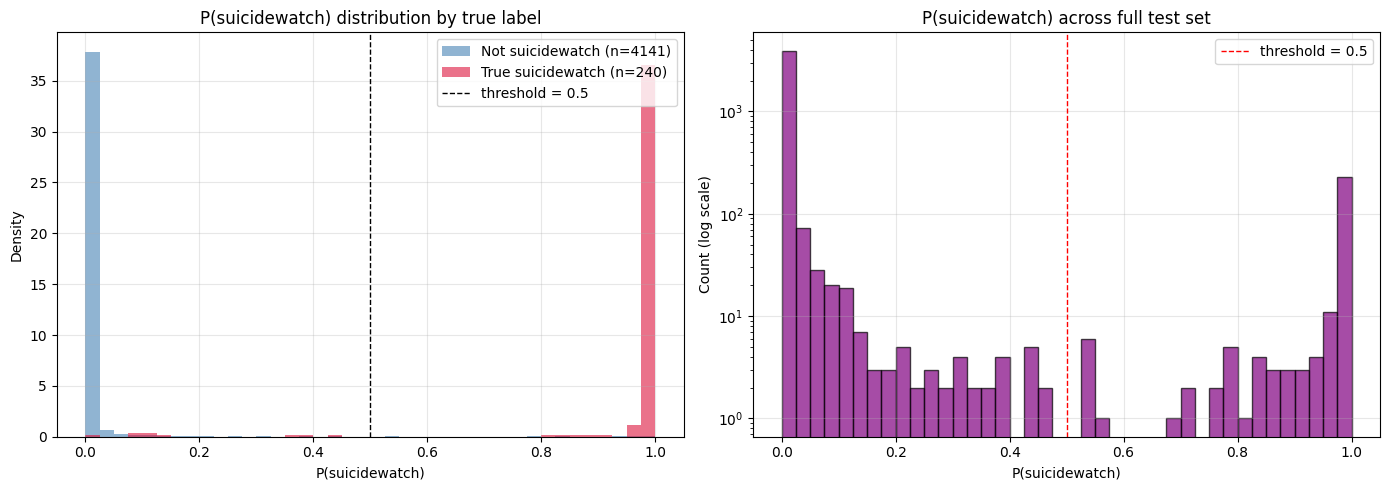


=== Stats for P(suicidewatch) ===
True suicidewatch samples (n=240):
  mean=0.9628  median=0.9976  std=0.1558
  % above 0.5: 96.2%

Other samples (n=4141):
  mean=0.0152  median=0.0004  std=0.0942
  % above 0.5: 1.1%


In [28]:
import matplotlib.pyplot as plt

def plot_suicidal_probability_distribution(model_path, result_dict, label_col='multiclass_label',
                                            suicidal_class='suicidewatch'):
    """
    Plot the distribution of P(suicidal) across the test set,
    split by true label (suicidal vs not).
    """
    class_names = result_dict['class_names']
    num_labels = len(class_names)

    if suicidal_class not in class_names:
        raise ValueError(f"'{suicidal_class}' not in class names: {class_names}")
    suicidal_idx = class_names.index(suicidal_class)

    # Rebuild model and load weights
    id2label = {i: n for i, n in enumerate(class_names)}
    label2id = {n: i for i, n in enumerate(class_names)}
    model = RobertaForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
    ).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Recreate the same test split used in run_experiment
    work = data.dropna(subset=[label_col, 'other_posts']).copy()
    counts = work[label_col].value_counts()
    keep = counts[counts >= 50].index.tolist()
    work = data.dropna(subset=[label_col, 'other_posts']).copy()
    work = work[work[label_col].isin(class_names)].reset_index(drop=True)  # <-- add this
    counts = work[label_col].value_counts()
    keep = counts[counts >= 50].index.tolist()
    work = work[work[label_col].isin(keep)].reset_index(drop=True)
    le = result_dict['label_encoder']
    work['_y'] = le.transform(work[label_col].astype(str))

    _, temp_df = train_test_split(work, test_size=0.2, random_state=42, stratify=work['_y'])
    _, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['_y'])
    test_df = test_df.reset_index(drop=True)

    # Tokenize and run inference, collecting P(suicidal)
    enc = tokenizer(test_df['other_posts'].tolist(), max_length=MAX_LENGTH,
                    padding='max_length', truncation=True, return_tensors='pt')
    ds = TextClassificationDataset(enc, test_df['_y'].values)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)

    all_probs, all_true = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc='Scoring'):
            batch = {k: v.to(device) for k, v in batch.items()}
            labels = batch.pop('labels')
            logits = model(**batch).logits
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)
            all_true.extend(labels.cpu().numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_true = np.array(all_true)
    suicidal_probs = all_probs[:, suicidal_idx]

    is_suicidal = (all_true == suicidal_idx)
    probs_pos = suicidal_probs[is_suicidal]
    probs_neg = suicidal_probs[~is_suicidal]

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: overlaid histograms
    bins = np.linspace(0, 1, 41)
    axes[0].hist(probs_neg, bins=bins, alpha=0.6, label=f'Not {suicidal_class} (n={len(probs_neg)})',
                 color='steelblue', density=True)
    axes[0].hist(probs_pos, bins=bins, alpha=0.6, label=f'True {suicidal_class} (n={len(probs_pos)})',
                 color='crimson', density=True)
    axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1, label='threshold = 0.5')
    axes[0].set_xlabel(f'P({suicidal_class})')
    axes[0].set_ylabel('Density')
    axes[0].set_title(f'P({suicidal_class}) distribution by true label')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Right: log-scale full test set
    axes[1].hist(suicidal_probs, bins=bins, color='purple', alpha=0.7, edgecolor='black')
    axes[1].set_yscale('log')
    axes[1].set_xlabel(f'P({suicidal_class})')
    axes[1].set_ylabel('Count (log scale)')
    axes[1].set_title(f'P({suicidal_class}) across full test set')
    axes[1].axvline(0.5, color='red', linestyle='--', linewidth=1, label='threshold = 0.5')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('suicidal_probability_distribution.png', dpi=120, bbox_inches='tight')
    plt.show()

    # Stats
    print(f'\n=== Stats for P({suicidal_class}) ===')
    print(f'True {suicidal_class} samples (n={len(probs_pos)}):')
    print(f'  mean={probs_pos.mean():.4f}  median={np.median(probs_pos):.4f}  '
          f'std={probs_pos.std():.4f}')
    print(f'  % above 0.5: {(probs_pos >= 0.5).mean() * 100:.1f}%')
    print(f'\nOther samples (n={len(probs_neg)}):')
    print(f'  mean={probs_neg.mean():.4f}  median={np.median(probs_neg):.4f}  '
          f'std={probs_neg.std():.4f}')
    print(f'  % above 0.5: {(probs_neg >= 0.5).mean() * 100:.1f}%')

    return suicidal_probs, all_true


# Filter to only include classes the model was trained on
# valid_classes = result_multiclass['class_names']
# work = data[data['multiclass_label'].isin(valid_classes)].copy()

# # Filter to only include classes the model was trained on
# work_filtered = work[work['multiclass_label'].isin(valid_classes)].copy()

# Pass the filtered dataframe to the plotting function
probs, true = plot_suicidal_probability_distribution(
    model_path='best_roberta_multiclass_v6.pt',
    result_dict=result_multiclass,
    label_col='multiclass_label',
    suicidal_class='suicidewatch',
)